# 04 — Method 3: BM25 + BERT Hybrid Retrieval
## UniMatch: Arabic Student Advising Chatbot

### Dataset Setup
| Role | File | Size |
|------|------|------|
| Index (knowledge base) | `faq_enhanced.csv` | 280 questions |
| Test queries | 4 paraphrases per question | 1,120 queries |

### Two-Stage Pipeline
```
Query
  ↓
Stage 1: BM25 → top-k candidates (fast lexical filter)
  ↓
Stage 2: BERT re-ranks candidates (semantic precision)
  ↓
Final Answer
```

## Cell 1 — Install

In [1]:
!pip install -q rank-bm25 sentence-transformers scikit-learn pandas matplotlib

## Cell 2 — Mount Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR   = '/content/drive/MyDrive/Student_chatbot/'
DATA_DIR   = os.path.join(BASE_DIR, 'data/')
MODEL_DIR  = os.path.join(BASE_DIR, 'models/')
RESULT_DIR = os.path.join(BASE_DIR, 'results/')

os.makedirs(RESULT_DIR, exist_ok=True)

print('Checking required files:')
for f in ['faq_enhanced.csv', 'bert_embeddings_v2.npy']:
    path = os.path.join(DATA_DIR if 'faq' in f else MODEL_DIR, f)
    print(f'  {f:30s} {"✅" if os.path.exists(path) else "❌ MISSING"}')

Mounted at /content/drive
Checking required files:
  faq_enhanced.csv               ✅
  bert_embeddings_v2.npy         ✅


## Cell 3 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('Imports done ✅')

Imports done ✅


## Cell 4 — Load Dataset

In [4]:
# Index = ALL questions (full knowledge base)
df_index = pd.read_csv(os.path.join(DATA_DIR, 'faq_enhanced.csv'))

# Build test queries — 4 paraphrases per question
long_rows = []
for _, row in df_index.iterrows():
    for col in ['question_alt', 'question_alt2',
                'question_alt3', 'question_alt4']:
        if col in row and pd.notna(row[col]):
            long_rows.append({
                'question': row['question'],
                'answer'  : row['answer'],
                'query'   : row[col],
            })

df_test = pd.DataFrame(long_rows)

print(f'Index (full)  : {len(df_index)} questions ✅')
print(f'Test queries  : {len(df_test)} queries ✅')
print(f'  ({len(df_index)} questions × 4 paraphrases)')
display(df_index.head(3))
display(df_test.head(4))

Index (full)  : 280 questions ✅
Test queries  : 1120 queries ✅
  (280 questions × 4 paraphrases)


,question,answer,question_alt,question_alt2,question_alt3,question_alt4
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟,منذ متى تأسست كلية الاقتصاد والأعمال؟
1,ما الهدف من إنشاء كلية الاقتصاد والأعمال؟,تهدف كلية الاقتصاد والأعمال إلى إعداد وتأهيل خ...,ما الغرض الذي أُسست من أجله كلية الاقتصاد والأ...,ما الغاية من إنشاء كلية الاقتصاد والأعمال؟,ما غرض إنشاء كلية الاقتصاد والأعمال؟,لماذا يُقدَّم إنشاء كلية الاقتصاد والأعمال؟
2,كم عدد الأقسام في كلية الاقتصاد والأعمال؟,تضم كلية الاقتصاد والأعمال خمسة أقسام.,كم قسمًا تحتوي كلية الاقتصاد والأعمال؟,ما عدد الأقسام في كلية الاقتصاد والأعمال؟,كم يبلغ عدد الأقسام في كلية الاقتصاد والأعمال؟,كم الأقسام في كلية الاقتصاد والأعمال يوجد؟


,question,answer,query
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
1,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
2,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟
3,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,منذ متى تأسست كلية الاقتصاد والأعمال؟


## Cell 5 — Load BERT Model & Embeddings

In [5]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'
print(f'Loading BERT model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)

# Load pre-computed embeddings from notebook 03b
emb_path = os.path.join(MODEL_DIR, 'bert_embeddings_v2.npy')
if os.path.exists(emb_path):
    bert_embeddings = np.load(emb_path)
    print(f'Embeddings loaded : {bert_embeddings.shape} ✅')
else:
    print('Computing embeddings (run notebook 03b first for speed)...')
    bert_embeddings = model.encode(
        df_index['question'].tolist(),
        batch_size           = 32,
        show_progress_bar    = True,
        normalize_embeddings = True
    )
    np.save(emb_path, bert_embeddings)
    print(f'Embeddings saved  : {bert_embeddings.shape} ✅')

Loading BERT model: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings loaded : (280, 384) ✅


## Cell 6 — Build BM25 Index
⚠️ Index built on `question` only — no paraphrases.

In [6]:
tokenized_questions = [q.split() for q in df_index['question'].tolist()]
bm25 = BM25Okapi(tokenized_questions)

print(f'BM25 index built ✅')
print(f'  Indexed questions  : {len(tokenized_questions)}')
print(f'  Avg tokens/question: {np.mean([len(t) for t in tokenized_questions]):.1f}')

BM25 index built ✅
  Indexed questions  : 280
  Avg tokens/question: 6.8


## Cell 7 — Hybrid Retrieval Function

In [7]:
def retrieve_hybrid(query, bm25, model, embeddings, df_index,
                    bm25_top_k=10, final_top_k=5):
    """
    Two-stage hybrid retrieval:
    Stage 1: BM25 retrieves top bm25_top_k candidates
    Stage 2: BERT re-ranks by semantic similarity
    """
    # Stage 1: BM25
    tokenized_query = query.split()
    bm25_scores     = bm25.get_scores(tokenized_query)
    bm25_top_idx    = np.argsort(bm25_scores)[::-1][:bm25_top_k]

    # Stage 2: BERT re-ranking
    cand_embeddings = embeddings[bm25_top_idx]
    q_emb           = model.encode([query], normalize_embeddings=True)
    bert_scores     = cosine_similarity(q_emb, cand_embeddings)[0]

    reranked_idx  = np.argsort(bert_scores)[::-1][:final_top_k]
    final_indices = bm25_top_idx[reranked_idx]

    top_k_results = [
        (df_index.iloc[i]['question'],
         float(bert_scores[reranked_idx[j]]))
        for j, i in enumerate(final_indices)
    ]

    best_global = final_indices[0]
    best_score  = float(bert_scores[reranked_idx[0]])

    return (
        df_index.iloc[best_global]['answer'],
        best_score,
        df_index.iloc[best_global]['question'],
        top_k_results
    )

print('Hybrid retrieval function defined ✅')

Hybrid retrieval function defined ✅


## Cell 8 — Test on Sample Queries

In [8]:
sample_queries = df_test['query'].sample(4, random_state=42).tolist()

print('BM25 + BERT Hybrid — Sample Results')
print('='*65)
for q in sample_queries:
    answer, score, matched, _ = retrieve_hybrid(
        q, bm25, model, bert_embeddings, df_index)
    print(f'\n  Query   : {q}')
    print(f'  Matched : {matched}')
    print(f'  Score   : {score:.4f}')
    print(f'  Answer  : {answer[:80]}...')
print('\n' + '='*65)

BM25 + BERT Hybrid — Sample Results

  Query   : ما معنى تأجيل الدراسة؟
  Matched : ما المقصود بتأجيل الدراسة؟
  Score   : 0.9482
  Answer  : تأجيل الدراسة هو إيقاف الطالب لدراسته بشكل مؤقّت لفترة محددة وفق أنظمة الجامعة، ...

  Query   : ما الهدف من دراسة تخصص المحاسبة والتدقيق المالي؟
  Matched : ما الغاية من دراسة تخصص المحاسبة والتدقيق المالي؟
  Score   : 0.9879
  Answer  : يهدف تخصص المحاسبة والتدقيق المالي إلى تزويد الخريجين بالمعرفة والكفاءات اللازمة...

  Query   : ما معنى الخدمات الإلكترونية في الجامعة بشكل عام؟
  Matched : ما هي الخدمات الإلكترونية في الجامعة؟
  Score   : 0.9345
  Answer  : هي مجموعة من الأنظمة والمواقع التي توفرها الجامعة للطلاب عبر الإنترنت، لتسهيل إن...

  Query   : هل يمكنك الإجابة عن: ما هي خطوات التسجيل للطالب الجديد؟
  Matched : ما هي خطوات التسجيل للطالب الجديد؟
  Score   : 0.9458
  Answer  : تبدأ الخطوات بتقديم طلب الالتحاق، ثم قبول الطالب، بعدها دفع الرسوم، وأخيرًا تسجي...



## Cell 9 — BM25 Candidate Pool Size Ablation

  BM25 k= 3 → Accuracy@1 = 80.0%
  BM25 k= 5 → Accuracy@1 = 86.7%
  BM25 k=10 → Accuracy@1 = 86.7%
  BM25 k=15 → Accuracy@1 = 86.7%
  BM25 k=20 → Accuracy@1 = 86.7%
  BM25 k=30 → Accuracy@1 = 86.7%


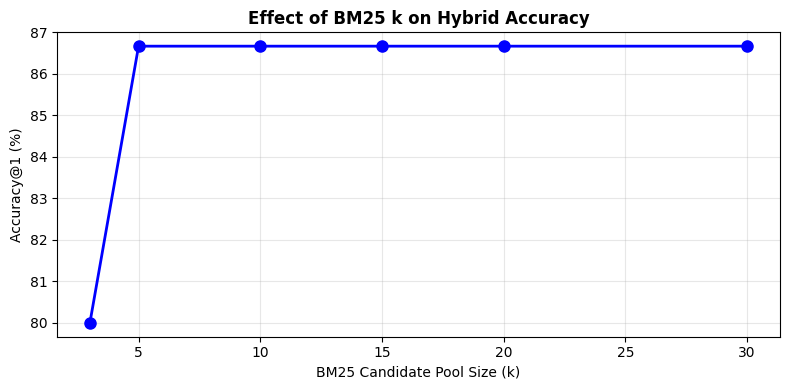


Best k = 5


In [9]:
sample_df = df_test.sample(30, random_state=42)
k_values  = [3, 5, 10, 15, 20, 30]
k_acc     = []

for k in k_values:
    correct = 0
    for _, row in sample_df.iterrows():
        answer, _, _, _ = retrieve_hybrid(
            row['query'], bm25, model,
            bert_embeddings, df_index, bm25_top_k=k)
        if answer.strip() == row['answer'].strip():
            correct += 1
    k_acc.append(correct / len(sample_df) * 100)
    print(f'  BM25 k={k:2d} → Accuracy@1 = {correct/len(sample_df)*100:.1f}%')

plt.figure(figsize=(8, 4))
plt.plot(k_values, k_acc, 'bo-', linewidth=2, markersize=8)
plt.xlabel('BM25 Candidate Pool Size (k)')
plt.ylabel('Accuracy@1 (%)')
plt.title('Effect of BM25 k on Hybrid Accuracy', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, 'hybrid_k_ablation_v2.png'), dpi=150)
plt.show()

best_k = k_values[np.argmax(k_acc)]
print(f'\nBest k = {best_k}')

## Cell 10 — Evaluation Function

In [10]:
def evaluate_hybrid(df_test, bm25, model, embeddings,
                    df_index, bm25_top_k=10):
    """
    Evaluate BM25+BERT Hybrid on test queries.

    df_test   : test queries — columns: [question, answer, query]
    df_index  : full knowledge base
    """
    correct_at1, correct_at3 = [], []
    rr_list, time_list       = [], []
    all_scores               = []

    for _, row in df_test.iterrows():
        query       = row['query']
        true_answer = row['answer']

        t_start = time.time()
        answer, score, _, top_k_res = retrieve_hybrid(
            query, bm25, model, embeddings, df_index,
            bm25_top_k=bm25_top_k, final_top_k=5
        )
        elapsed = (time.time() - t_start) * 1000

        # Get top-5 answers
        top5_ans = []
        for q_text, _ in top_k_res:
            match = df_index[df_index['question'] == q_text]
            if len(match) > 0:
                top5_ans.append(match.iloc[0]['answer'])

        # Accuracy@1
        correct_at1.append(answer.strip() == true_answer.strip())

        # Accuracy@3
        correct_at3.append(
            true_answer.strip() in
            [a.strip() for a in top5_ans[:3]])

        # MRR
        rr = 0
        for rank, ans in enumerate(top5_ans, 1):
            if ans.strip() == true_answer.strip():
                rr = 1 / rank
                break
        rr_list.append(rr)
        time_list.append(elapsed)
        all_scores.append(score)

    return {
        'Accuracy@1'   : np.mean(correct_at1) * 100,
        'Accuracy@3'   : np.mean(correct_at3) * 100,
        'MRR'          : np.mean(rr_list),
        'Avg Score'    : np.mean(all_scores),
        'Avg Time (ms)': np.mean(time_list),
        'details'      : {
            'correct_at1': correct_at1,
            'scores'     : all_scores,
        }
    }

print('Evaluation function defined ✅')

Evaluation function defined ✅


## Cell 11 — Run Evaluation

In [11]:
print(f'Running Hybrid evaluation (BM25 k={best_k})...')
print(f'  Index size : {len(df_index)} questions')
print(f'  Test size  : {len(df_test)} queries')

metrics = evaluate_hybrid(
    df_test, bm25, model, bert_embeddings,
    df_index, bm25_top_k=best_k)

print('\n' + '='*50)
print('  BM25 + BERT HYBRID EVALUATION RESULTS')
print('='*50)
print(f'  Accuracy@1    : {metrics["Accuracy@1"]:.2f}%')
print(f'  Accuracy@3    : {metrics["Accuracy@3"]:.2f}%')
print(f'  MRR           : {metrics["MRR"]:.4f}')
print(f'  Avg Score     : {metrics["Avg Score"]:.4f}')
print(f'  Avg Time (ms) : {metrics["Avg Time (ms)"]:.2f}')
print(f'  BM25 k        : {best_k}')
print(f'  Index size    : {len(df_index)}')
print(f'  Test queries  : {len(df_test)}')
print('='*50)

Running Hybrid evaluation (BM25 k=5)...
  Index size : 280 questions
  Test size  : 1120 queries

  BM25 + BERT HYBRID EVALUATION RESULTS
  Accuracy@1    : 90.80%
  Accuracy@3    : 95.36%
  MRR           : 0.9290
  Avg Score     : 0.9194
  Avg Time (ms) : 11.57
  BM25 k        : 5
  Index size    : 280
  Test queries  : 1120


## Cell 12 — Final Comparison: All 3 Methods

All 3 Methods — Final Comparison (Enhanced Dataset):


,Method,Accuracy@1,Accuracy@3,MRR,Avg Score,Avg Time (ms)
0,TF-IDF,90.0900,98.0400,0.9399,0.8008,1.5900
1,Sentence-BERT,92.5900,97.9500,0.9528,0.9312,45.8800
2,BM25+BERT Hybrid,90.8036,95.3571,0.9290,0.9194,11.5738


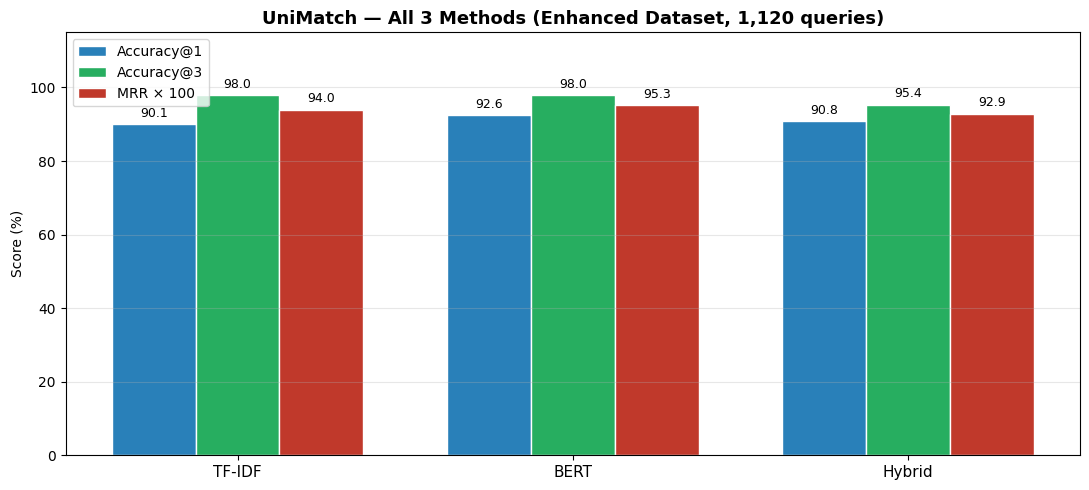

Plot saved ✅


In [12]:
# Results from notebooks 02b and 03b
all_results = {
    'TF-IDF'           : {'Accuracy@1': 90.09, 'Accuracy@3': 98.04,
                          'MRR': 0.9399, 'Avg Score': 0.8008,
                          'Avg Time (ms)': 1.59},
    'Sentence-BERT'    : {'Accuracy@1': 92.59, 'Accuracy@3': 97.95,
                          'MRR': 0.9528, 'Avg Score': 0.9312,
                          'Avg Time (ms)': 45.88},
    'BM25+BERT Hybrid' : {
        'Accuracy@1'   : metrics['Accuracy@1'],
        'Accuracy@3'   : metrics['Accuracy@3'],
        'MRR'          : metrics['MRR'],
        'Avg Score'    : metrics['Avg Score'],
        'Avg Time (ms)': metrics['Avg Time (ms)'],
    }
}

compare_df = pd.DataFrame(all_results).T.round(4)
compare_df.index.name = 'Method'
compare_df.reset_index(inplace=True)
print('All 3 Methods — Final Comparison (Enhanced Dataset):')
display(compare_df)

# Bar chart
methods = list(all_results.keys())
colors  = ['#2980b9', '#8e44ad', '#d35400']
x       = np.arange(len(methods))
w       = 0.25

acc1 = [all_results[m]['Accuracy@1'] for m in methods]
acc3 = [all_results[m]['Accuracy@3'] for m in methods]
mrr  = [all_results[m]['MRR'] * 100  for m in methods]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, acc1, w, label='Accuracy@1', color='#2980b9', edgecolor='white')
b2 = ax.bar(x,     acc3, w, label='Accuracy@3', color='#27ae60', edgecolor='white')
b3 = ax.bar(x + w, mrr,  w, label='MRR × 100',  color='#c0392b', edgecolor='white')
ax.bar_label(b1, labels=[f'{v:.1f}' for v in acc1], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f'{v:.1f}' for v in acc3], padding=3, fontsize=9)
ax.bar_label(b3, labels=[f'{v:.1f}' for v in mrr],  padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['TF-IDF', 'BERT', 'Hybrid'], fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('UniMatch — All 3 Methods (Enhanced Dataset, 1,120 queries)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, 'all_methods_v2.png'), dpi=150)
plt.show()
print('Plot saved ✅')

## Cell 13 — Save All Results

In [13]:
# Save hybrid metrics
hybrid_df = pd.DataFrame([{
    'Method'       : 'BM25+BERT Hybrid',
    'Accuracy@1'   : round(metrics['Accuracy@1'], 2),
    'Accuracy@3'   : round(metrics['Accuracy@3'], 2),
    'MRR'          : round(metrics['MRR'], 4),
    'Avg Score'    : round(metrics['Avg Score'], 4),
    'Avg Time (ms)': round(metrics['Avg Time (ms)'], 2),
    'BM25_k'       : best_k,
    'Index Size'   : len(df_index),
    'Test Queries' : len(df_test),
}])
hybrid_df.to_csv(
    os.path.join(RESULT_DIR, 'hybrid_results_v2.csv'), index=False)
compare_df.to_csv(
    os.path.join(RESULT_DIR, 'all_methods_v2.csv'), index=False)

print('='*55)
print('  SAVED FILES')
print('='*55)
print(f'  results/hybrid_results_v2.csv')
print(f'  results/all_methods_v2.csv')
print(f'  results/all_methods_v2.png')
print(f'  results/hybrid_k_ablation_v2.png')
print('='*55)
display(hybrid_df)

best_acc = compare_df.loc[compare_df['Accuracy@1'].idxmax(), 'Method']
fastest  = compare_df.loc[compare_df['Avg Time (ms)'].idxmin(), 'Method']
print(f'\n🏆 Best Accuracy@1 : {best_acc}')
print(f'⚡ Fastest method  : {fastest}')
print(f'\nNext → 05_evaluation_comparison.ipynb')

  SAVED FILES
  results/hybrid_results_v2.csv
  results/all_methods_v2.csv
  results/all_methods_v2.png
  results/hybrid_k_ablation_v2.png


,Method,Accuracy@1,Accuracy@3,MRR,Avg Score,Avg Time (ms),BM25_k,Index Size,Test Queries
0,BM25+BERT Hybrid,90.8,95.36,0.929,0.9194,11.57,5,280,1120



🏆 Best Accuracy@1 : Sentence-BERT
⚡ Fastest method  : TF-IDF

Next → 05_evaluation_comparison.ipynb
